# Digit Recognizer


## Introduction
* Computer vision is a field of artificial intelligence (AI) that enables computers and systems to derive meaningful information from digital images, videos and other visual inputs — and take actions or make recommendations based on that information.
* From the perspective of engineering, it seeks to understand and automate tasks that the human visual system can do.

### Computer vision
* Computer vision is a field of artificial intelligence (AI) that enables computers and systems to derive meaningful information from digital images, videos and other visual inputs — and take actions or make recommendations based on that information.
* From the perspective of engineering, it seeks to understand and automate tasks that the human visual system can do.

### Objective

The goal is to correctly identify digits from a dataset of tens of thousands of handwritten images.

## Import dependencies

In [1]:
# import the necessary libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV

## Import dataset

* We will be using the **[MNIST dataset](http://yann.lecun.com/exdb/mnist/index.html)**. MNIST is an acronym that stands for the Modified National Institute of Standards and Technology dataset.
* It is a dataset of 60,000 small square grayscale images of handwritten single digits between 0 and 9.
* Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255, inclusive.
* The training data set has 785 columns. The first column, called "label", is the digit that was drawn by the user. The rest of the columns contain the pixel-values of the associated image.
* Each pixel column in the training set has a name like pixelx, where x is an integer between 0 and 783, inclusive. To locate this pixel on the image, suppose that we have decomposed x as x = i * 28 + j, where i and j are integers between 0 and 27, inclusive. Then pixelx is located on row i and column j of a 28 x 28 matrix, (indexing by zero).
* The test data set is the same as the training set, except that it does not contain the "label" column.


In [2]:
# import dataset
url_train="https://raw.githubusercontent.com/sabaak95/mnist/main/mnist_train.csv"
train= pd.read_csv(url_train)
#test =
url_test="https://raw.githubusercontent.com/sabaak95/mnist/main/mnist_test.csv"
test = pd.read_csv (url_test)

In [3]:
#now use a function to print number of rows and columns of both datasets
print("shape of train dataset",train.shape)

shape of train dataset (42000, 785)


In [4]:
print("shape of test dataset", test.shape)

shape of test dataset (28000, 784)


In [5]:
#now here, we will divide things into different sets

y = train["label"]
X = train.drop(["label"],axis = 1)
X_test = test

In [6]:
y.head()

,label
0,1
1,0
2,1
3,4
4,0


## Preprocess data

In [7]:
# Normalization (so that they get in the same range)
#Hint:normalize X and X_test to "0 to 1" range
X = X/255.0
X_test = X_test/255.0

In [8]:
# setting train and validation data
nr_samples = 30000
#Hint: Choose first 30000 images as training data and next 10000 as validation data
y_train = y[:nr_samples]
X_train = X[:nr_samples]

start_ix_val=nr_samples
end_ix_val = nr_samples + int(nr_samples/3)

y_val = y[start_ix_val:end_ix_val]
x_val = X[start_ix_val:end_ix_val]

print("nr_samples train data:", nr_samples)
print("start_ix_val:", start_ix_val)
print("end_ix_val:", end_ix_val)

nr_samples train data: 30000
start_ix_val: 30000
end_ix_val: 40000


## Analyze the data

In [9]:
#Now lets analyze our data a bit

print("X:")
#Hint: info function
print(X.info())

# print a line of aestriks :)
print("*"*50)

# printing the test
print ("X_test:")

#hint: info function
print (X_test.info())
#another line of aestriks maybe?
print("*"*50)

#printing the y
print("y:")
print(y.shape)

X:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 784 entries, pixel0 to pixel783
dtypes: float64(784)
memory usage: 251.2 MB
None
**************************************************
X_test:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Columns: 784 entries, pixel0 to pixel783
dtypes: float64(784)
memory usage: 167.5 MB
None
**************************************************
y:
(42000,)


# Taking a closer look at the data


In [10]:
X.iloc[0:5,:]

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
y.iloc[0:5]

,label
0,1
1,0
2,1
3,4
4,0


## Visualize some images
now lets print out the actual pixel to make things more "visual"


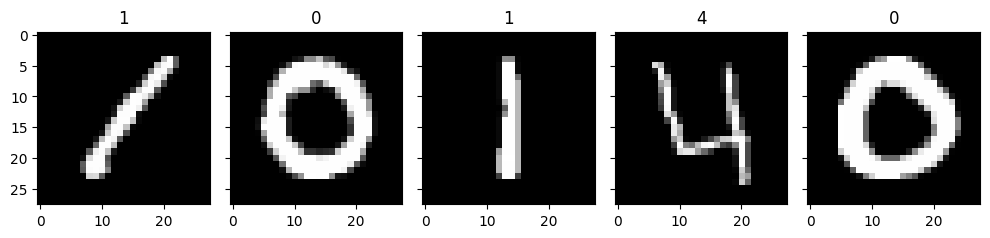

In [12]:
#Visualize the normalized images

#Hint: Let's create a subfigure with 1 row and 5 columns with sharex=True, sharey=True, figsize=(10,6)
fig, axs = plt.subplots(1,5, sharex=True, sharey=True, figsize=(10,6))
axs = axs.flatten()

# using a for loop to go through a specific range
for i in range(0,5):
    im = X.iloc[i]
    # Hint: using reshape
    im = im.values.reshape(-1,28,28,1)
    #hint: using imshow, cmap
    axs[i].imshow(im[0,:,:,0], cmap=plt.get_cmap('gray'))
    axs[i].set_title(y[i])

plt.tight_layout()

In [13]:
# Distribution of labels
#Hint: use value_counts() to get distribution of labels
y.value_counts()

,count
label,
1,4684
7,4401
3,4351
9,4188
2,4177
6,4137
0,4132
4,4072
8,4063


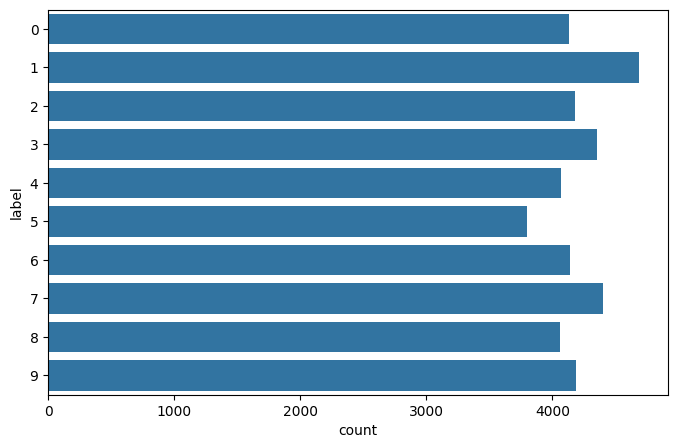

In [14]:
# Use the countplot to visualize the counts of each digits
fig, ax = plt.subplots(figsize=(8,5))
g = sns.countplot(y = train["label"])

### Visualize some images

In [15]:
# get indexes of first 10 occurences for each number
li_idxs = []
for i in range(10):
    for nr in range(10):
        ix = y[y==nr].index[i]
        li_idxs.append(ix)
print(li_idxs)

[np.int64(1), np.int64(0), np.int64(16), np.int64(7), np.int64(3), np.int64(8), np.int64(21), np.int64(6), np.int64(10), np.int64(11), np.int64(4), np.int64(2), np.int64(22), np.int64(9), np.int64(32), np.int64(19), np.int64(26), np.int64(18), np.int64(20), np.int64(27), np.int64(5), np.int64(12), np.int64(24), np.int64(13), np.int64(39), np.int64(51), np.int64(45), np.int64(29), np.int64(30), np.int64(28), np.int64(17), np.int64(15), np.int64(34), np.int64(14), np.int64(42), np.int64(62), np.int64(64), np.int64(47), np.int64(67), np.int64(31), np.int64(23), np.int64(35), np.int64(44), np.int64(25), np.int64(43), np.int64(80), np.int64(72), np.int64(48), np.int64(82), np.int64(33), np.int64(54), np.int64(37), np.int64(55), np.int64(36), np.int64(49), np.int64(99), np.int64(74), np.int64(50), np.int64(87), np.int64(40), np.int64(63), np.int64(38), np.int64(56), np.int64(46), np.int64(66), np.int64(107), np.int64(89), np.int64(76), np.int64(105), np.int64(53), np.int64(69), np.int64(41),

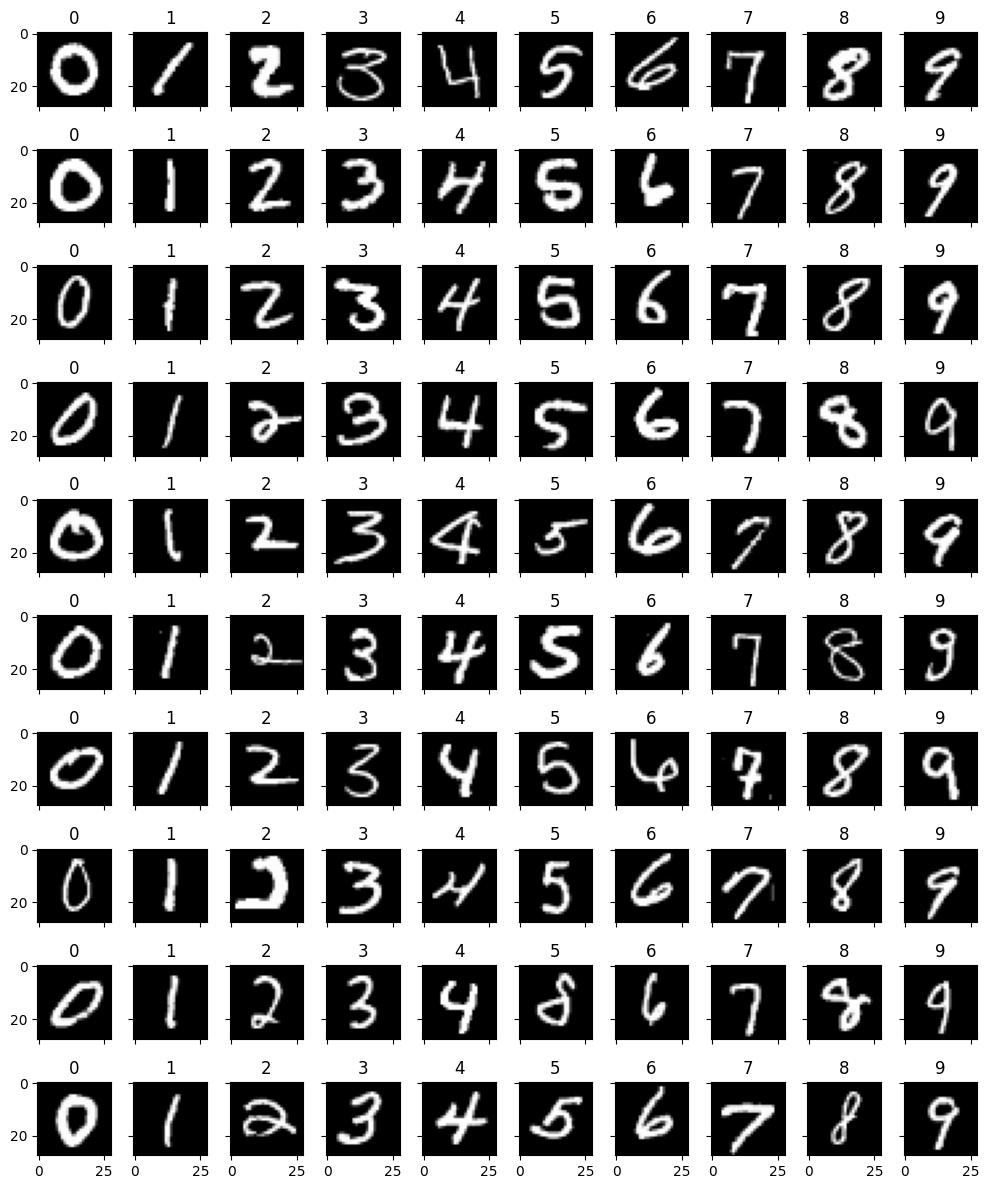

In [16]:
# now use the same technique from above to show the
# first 10 image samples for each digit
fig, axs = plt.subplots(10,10, sharex=True, sharey=True, figsize=(10,12))
axs = axs.flatten()

for n,i in enumerate(li_idxs):
    im = X.iloc[i]
    # Hint: using reshape function
    im = im.values.reshape(-1,28,28,1)
    #hint: using imshow, cmap
    axs[n].imshow(im[0,:,:,0], cmap=plt.get_cmap('gray'))
    axs[n].set_title(y[i])
plt.tight_layout()

### Some remarks

1. **We can see that there is a lot of variety in the look of the numbers**  
2. **The digits are obviously written by many different people**
3. **And it seems that there might be difficulties identifying some of the digits correctly also for humans**
  * The 6s in row 0 1 and 6 look close to a 4  
  * The 5 in row 1 looks close to a 6 and the 5 in row 8 looks close to a 8  
  * The 4 in row 4 is wriiten differently as the other 4s and the 4 in row 7 almost looks like a 7  
  * The 8 in row 8 is wriiten differently as the other 8s  




## Create and evaluate models

In this project, we're creating 3 different types of model for our digit classification task:
* **Logistic Regression (LR)**
* **Random Forest (RF)**
* **Support Vector Machines (SVM)**

### Evaluate model function

In [17]:
# Get best score from GridSearchCV
def get_best_score(model):

    print(model.best_score_)
    print(model.best_params_)
    print(model.best_estimator_)

    return model.best_score_

# print classification report and accuracy
def print_validation_report(y_true, y_pred):
    print("Classification Report")
    print(classification_report(y_true, y_pred))
    acc_sc = accuracy_score(y_true, y_pred)
    print("Accuracy : "+ str(acc_sc))

    return acc_sc

# print confusion matrix
def plot_confusion_matrix(y_true, y_pred):
    mtx = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8,8))
    sns.heatmap(mtx, annot=True, fmt='d', linewidths=.5,  cbar=False, ax=ax)
    #  square=True,
    plt.ylabel('true label')
    plt.xlabel('predicted label')

## Logistic regression

In [18]:
#Import LogisticRegression from sklearn and create the model function
from sklearn.linear_model import LogisticRegression
LRmodel = LogisticRegression(random_state=0)

###Hyperparameter tuning
Machine learning algorithms have hyperparameters that allow you to tailor the behavior of the algorithm to your specific dataset.

Create the parameter grid and initialize GridSearchCV function

param_grid must contain the following parameters: 'C', 'multi_class', 'penalty', 'solver', and 'tol'

'penalty': 'l1' means L1 regularization is chosen to make the model less complex and avoid overfitting.

'C' describes the inverse of regularization strength.

'solver':'saga' is a solver algorithm for optimization

'tol': '0.1' tol is the tolerance for the stopping criteria

In [19]:
## Hint: create a dictionary callerd param_frid with C=[0.014, 0.012], multi_class=['multinomial'], penalty=['l1'], solver=['saga'], tol=[0.1]
param_grid = {'C': [0.01, 0.012, 0.014, 0.016, 0.02],
              'multi_class':['multinomial', 'ovr'],
              'penalty':['l1', 'l2'],
              'solver':['saga', 'newton-cg', 'lbfgs', 'liblinear'],
              'tol':[0.001, 0.01, 0.1, 1]}

GridSearchCV must contain the following input parameters: The logistic regression model, the parameter grid, verbose, and cv

cv: cross-validation, the number of cv folds for each combination of parameters

verbose: the option given to an ML training function to denote how much logging output is to be produced. When verbose = 1, which includes both progress bar and one line per epoch. verbose = 0, means silent.

In [20]:
#create and initialize GridSearchCV function
#Hint: fill in the dotted parts with proper variables
GridCV_LR = GridSearchCV(LRmodel, param_grid, verbose=1, cv=5)

In [ ]:
#Fit the GridSearchCV model and get the best score
## use .fit(train_input,train_output) to train the model. Use proper input and outputs
GridCV_LR.fit(X_train, y_train)
get_best_score(GridCV_LR)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
#Predict using the model
##Hint: use .predict(test_input) to make predictions
pred_cal_lr = GridCV_LR.predict(x_val)

###Plot the classification and confusion matrix

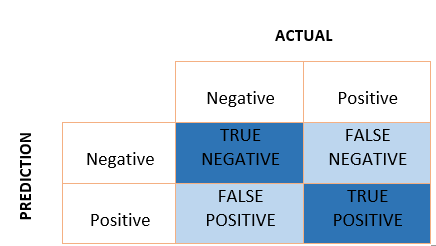

Precision: Gives us the proportion of positive predictions that were actually correct. It is the ratio between the True Positives and all the Positives.

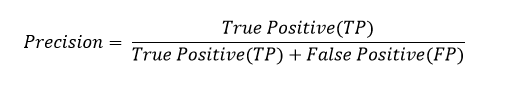

Recall: Gives us the proportion of true positives that were identified correctly.
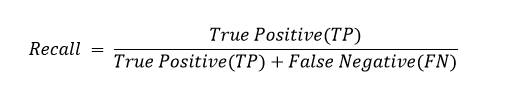

F1 score: It is the harmonic mean of precision and recall. It takes both false positive and false negatives into account. Therefore, it performs well on an imbalanced dataset.

Support: Support is the number of actual occurrences of the class in the specified dataset.

In [ ]:
#Get classification report containing precision, recall, f1-score and support
## Hint: Use print_validation_report fucntion with proper inputs
acc_lr = print_validation_report(pred_cal_lr,y_val)

In [ ]:
#Plot the confusion matrix
## Hint: Use plot_confusion_matrix fucntion with proper inputs

plot_confusion_matrix(pred_cal_lr,y_val)

## Activity 1
Change up param_grid to contain 'C': [0.02,0.014], train the model and plot confusion matrix. Observe the accuracy value, does it increase?
Previously the model with 'C'=0.014 was chosen as the best out of the two models evaluated for 'C': [0.014,0.012]

In [ ]:
#Enter your code here
param_grid = {'C': [0.02, 0.014], 'multi_class': ['multinomial'],
              'penalty': ['l1'],'solver': ['saga'], 'tol': [0.1] }

In [ ]:
GridCV_LR = GridSearchCV(LRmodel, param_grid, verbose=1, cv=5)

In [ ]:
GridCV_LR.fit(X_train,y_train)
score_grid_LR = get_best_score(GridCV_LR)

In [ ]:
## make predictions
pred_val_lr = GridCV_LR.predict(x_val)

In [ ]:
acc_lr = print_validation_report(y_val, pred_val_lr)

In [ ]:
plot_confusion_matrix(y_val, pred_val_lr)

### Random forest classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

## define a Random Forest classifier with random_state=0
clf_RF = RandomForestClassifier(random_state=0)
## define param_grid as a dictionary with a 'max_depth' =15 , 'max_features'=100, 'min_samples_split'=5 and 'n_estimators'=50
param_grid = {'max_depth': [15], 'max_features': [100],
              'min_samples_split':[5], 'n_estimators':[50]}

## Do a GridSearchCV with the created randomforest function (clf_RF) and param_grid with verbose=1 and cv=5
GridCV_RF = GridSearchCV(clf_RF,param_grid,verbose=1,cv=5)

## Use GridCV_RF.fit with proper inputs to train your model
GridCV_RF.fit(X_train,y_train)

## Use the "get_best_score" function to get score_grid_RF
score_grid_RF = get_best_score(GridCV_RF)


In [ ]:
## Use GridCV_RF.predict with X_val as inputs to predict with the model
pred_val_rf = GridCV_RF.predict(x_val)

In [ ]:
acc_rf = print_validation_report(y_val, pred_val_rf)

In [ ]:
plot_confusion_matrix(y_val, pred_val_rf)

### Support vector machine


GridSearchCV for SVM takes very long, so we will only fit one good set of parameters here.

In [ ]:
from sklearn.svm import SVC
## define a SVC with a "Regularization parameter" or "C" of 5, "gamma" of 0.05 , 'rbf' kernel and random_state = 0
clf_svm = SVC(C=5, gamma=0.05, kernel='rbf', random_state=0)
## Use clf_svm.fit with proper inputs to train your model
clf_svm.fit(X_train,y_train)

In [ ]:
## make prediction for X_val with clf_svm.predict function
pred_val_svm = clf_svm.predict(x_val)
acc_svm = print_validation_report(y_val, pred_val_svm)

In [ ]:
print(GridCV_LR.best_params_)
GridCV_LR.best_estimator_.fit(X,y)

In [ ]:
plot_confusion_matrix(y_val, pred_val_svm)

## Which is the best model?

In [ ]:
#Build a dataframe containing the accuracy scores for each model trained so far.
#Insert your code here
models = pd.DataFrame({
    'Model':['Logistic Regression', 'Random Forest Classifier', 'SVC'],
    'Score':[acc_lr, acc_rf, acc_svm ]
})

In [ ]:
models.sort_values(by = 'Score', ascending=False)

## Activity 2

* Best model for digit classification?
* Do you think any of the above models do better than human accuracy for recognizing hand written digits?


## Investigating false predictions

In [ ]:
#Hint: initialize the ground truth values to a variable using .values
arr_y_val = y_val.values

#Hint: Find the false predicted values using Support Vector Classifier using pred_val_svm!=...
false_svm = pred_val_svm != arr_y_val

In [ ]:
#Hint: Print the shape of the false predicted values to find the count
false_svm[false_svm == True].shape

There are 192 false predicted values by SVM model. Lets try printing some.

In [ ]:
# Let's plot 25 false predicted results
#Hint: create a subplot which is 5x5 and sharex=True, sharey=True, figsize=(10,12)
fig, axs = plt.subplots(5, 5, sharex=True, sharey=True, figsize=(10,12))
axs = axs.flatten()
j = 0
for i, n  in enumerate(false_svm):
  ##Hint: Using if, only pick the first 25 that are falsly predicted
  if n and j < 25:
    im = x_val.iloc[i]
    ## Hint: use .values and reshape to create some 28x28x1 images
    im = im.values.reshape(28,28,1)
    ## Hint: use imshow to plot im[0,:,:,0] with cmap set as gray
    axs[j].imshow(im[:,:,0], cmap='gray')
    title = ("predicted: " + str(pred_val_svm[i]) + "\n" + "true: " + str(arr_y_val[i]) )
    ## Hint: set the "title" as the plot titles with ".set_title" function
    axs[j].set_title(title)
    j = j+1
plt.tight_layout()

##Activity 3


Investigate false predictions for Logistic Regression and Random Forest Classifier. Does your answer for the best model change after this?

In [ ]:
#Random forest classifier
#Hint: initialize the ground truth values to a variable
arr_y_val = y_val.values

# Hint:Find the false predicted values using Support Vector Classifier
false_rf = pred_val_rf != arr_y_val

In [ ]:
#Hint:Print the shape of the false predicted values to find the count
false_rf[false_rf == True].shape

In [ ]:
# Let's plot 25 false predicted results
#Hint: create a subplot which is 5x5 and sharex=True, sharey=True, figsize=(10,12)
fig, axs = plt.subplots(5, 5, sharex=True, sharey=True, figsize=(10,12))
axs = axs.flatten()
j = 0
for i, n  in enumerate(false_rf):
  ##Hint: Using if, only pick the first 25 that are falsly predicted
  if n and j < 25:
    im = x_val.iloc[i]
    ## Hint: use .values and reshape to create some 28x28x1 images
    im = im.values.reshape(28,28,1)
    ## Hint: use imshow to plot im[0,:,:,0] with cmap set as gray
    axs[j].imshow(im[:,:,0], cmap='gray')
    title = ("predicted: " + str(pred_val_rf[i]) + "\n" + "true: " + str(arr_y_val[i]) )
    ## Hint: set the "title" as the plot titles with ".set_title" function
    axs[j].set_title(title)
    j = j+1
plt.tight_layout()

In [ ]:
#Logistic Regression
##Hint: initialize the ground truth values to a variable
arr_y_val = y_val.values

# #Hint:Find the false predicted values using LR
false_lr = pred_val_lr != arr_y_val

In [ ]:
#Hint:Print the shape of the false predicted values to find the count
false_lr[false_lr == True].shape

In [ ]:
# Let's plot 25 false predicted results
#Hint: create a subplot which is 5x5 and sharex=True, sharey=True, figsize=(10,12)
fig, axs = plt.subplots(5, 5, sharex=True, sharey=True, figsize=(10,12))
axs = axs.flatten()
j = 0
for i, n  in enumerate(false_lr):
  ##Hint: Using if, only pick the first 25 that are falsly predicted
  if n and j < 25:
    im = x_val.iloc[i]
    ## Hint: use .values and reshape to create some 28x28x1 images
    im = im.values.reshape(28,28,1)
    ## Hint: use imshow to plot im[0,:,:,0] with cmap set as gray
    axs[j].imshow(im[:,:,0], cmap='gray')
    title = ("predicted: " + str(pred_val_lr[i]) + "\n" + "true: " + str(arr_y_val[i]) )
    ## Hint: set the "title" as the plot titles with ".set_title" function
    axs[j].set_title(title)
    j = j+1
plt.tight_layout()